# Notebook to chose the best regularizations for the final main3.py

In [9]:
import glob
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, recall_score, f1_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
import sys
import os
# Obtenemos la ruta absoluta del directorio padre (la raíz del proyecto)
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

# Importamos mis modulos personalizados
from src.data_processing import DataProcessor
from src.random_forest import SpotifyRandomForest
import pandas as pd


# 1. CARGA Y PROCESAMIENTO
# ==========================================
json_files = glob.glob("../data/Streaming_History_Audio_2026*.json")
processor = DataProcessor(json_paths=json_files)
X, y = processor.process()

## Separación de datos

In [10]:

# 2. SEPARACIÓN TRIPARTITA (Train 70% / Val 15% / Test 15%)
# ==========================================
# Sacamos el 15% para el Test final (aislado totalmente)
test_data = 0.15
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=test_data, random_state=42, stratify=y
)
# Del 85% restante, sacamos la validación (0.15 / 0.85)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=test_data/0.85, random_state=42, stratify=y_temp
)

print(f"-> DISTRIBUCIÓN DE DATOS")
print(f"Total de muestras: {len(y)}")
print(f"Train: {len(y_train)} muestras")
print(f"Validation: {len(y_val)} muestras")
print(f"Test: {len(y_test)} muestras\n")

-> DISTRIBUCIÓN DE DATOS
Total de muestras: 10589
Train: 7411 muestras
Validation: 1589 muestras
Test: 1589 muestras



## Modelo Base

In [11]:
print("-> MODELO BASE (Sin Regularizar)")
# Modelo muy extenso y especifico forzado dado n_estimators y n_estimators grandes
rf_base = SpotifyRandomForest()
rf_base.fit(X_train, y_train, feature_names=processor.feature_names)

# Evaluamos
y_pred_train_base = rf_base.predict(X_train)
y_pred_val_base = rf_base.predict(X_val)

# Metricas
acc_train_base = accuracy_score(y_train, y_pred_train_base)
acc_val_base = accuracy_score(y_val, y_pred_val_base)
rec_train_base = recall_score(y_train, y_pred_train_base)
rec_val_base = recall_score(y_val, y_pred_val_base)
f1_train_base = f1_score(y_train, y_pred_train_base)
f1_val_base = f1_score(y_val, y_pred_val_base)

print('-> Métricas del modelo base')
print(f"Accuracy en Train: {acc_train_base:.2%}")
print(f"Accuracy en Validation: {acc_val_base:.2%}")
print(f"Recall en Train: {rec_train_base:.2%}")
print(f"Recall en Validation: {rec_val_base:.2%}")
print(f"F1-score en Train: {f1_train_base:.2%}")
print(f"F1-score en Validation: {f1_val_base:.2%}")

# Diagnóstico automático 
if acc_train_base > 0.95 and (acc_train_base - acc_val_base) > 0.05:
    print(">> DIAGNÓSTICO: ALTA VARIANZA (OVERFITTING). El modelo memoriza el Train pero pierde precisión en Validación.")
elif acc_train_base < 0.70:
    print(">> DIAGNÓSTICO: ALTO SESGO (UNDERFITTING). El modelo no logra aprender los patrones.")
else:
    print(">> DIAGNÓSTICO: AJUSTE ACEPTABLE (FIT).")

print("\nReporte en Validación (Modelo Base):")
print(classification_report(y_val, y_pred_val_base))

-> MODELO BASE (Sin Regularizar)
-> Métricas del modelo base
Accuracy en Train: 87.42%
Accuracy en Validation: 78.92%
Recall en Train: 72.13%
Recall en Validation: 52.72%
F1-score en Train: 68.02%
F1-score en Validation: 48.06%
>> DIAGNÓSTICO: AJUSTE ACEPTABLE (FIT).

Reporte en Validación (Modelo Base):
              precision    recall  f1-score   support

           0       0.89      0.85      0.87      1295
           1       0.44      0.53      0.48       294

    accuracy                           0.79      1589
   macro avg       0.66      0.69      0.67      1589
weighted avg       0.81      0.79      0.80      1589



## Curvas de validación

### StratifiedKFold

-> MATRIZ DE CURVAS DE VALIDACIÓN
Evaluando max_depth, n_estimators y min_samples_split con CV de 5 pliegues

Curvas de validación para valores númericos


KeyboardInterrupt: 

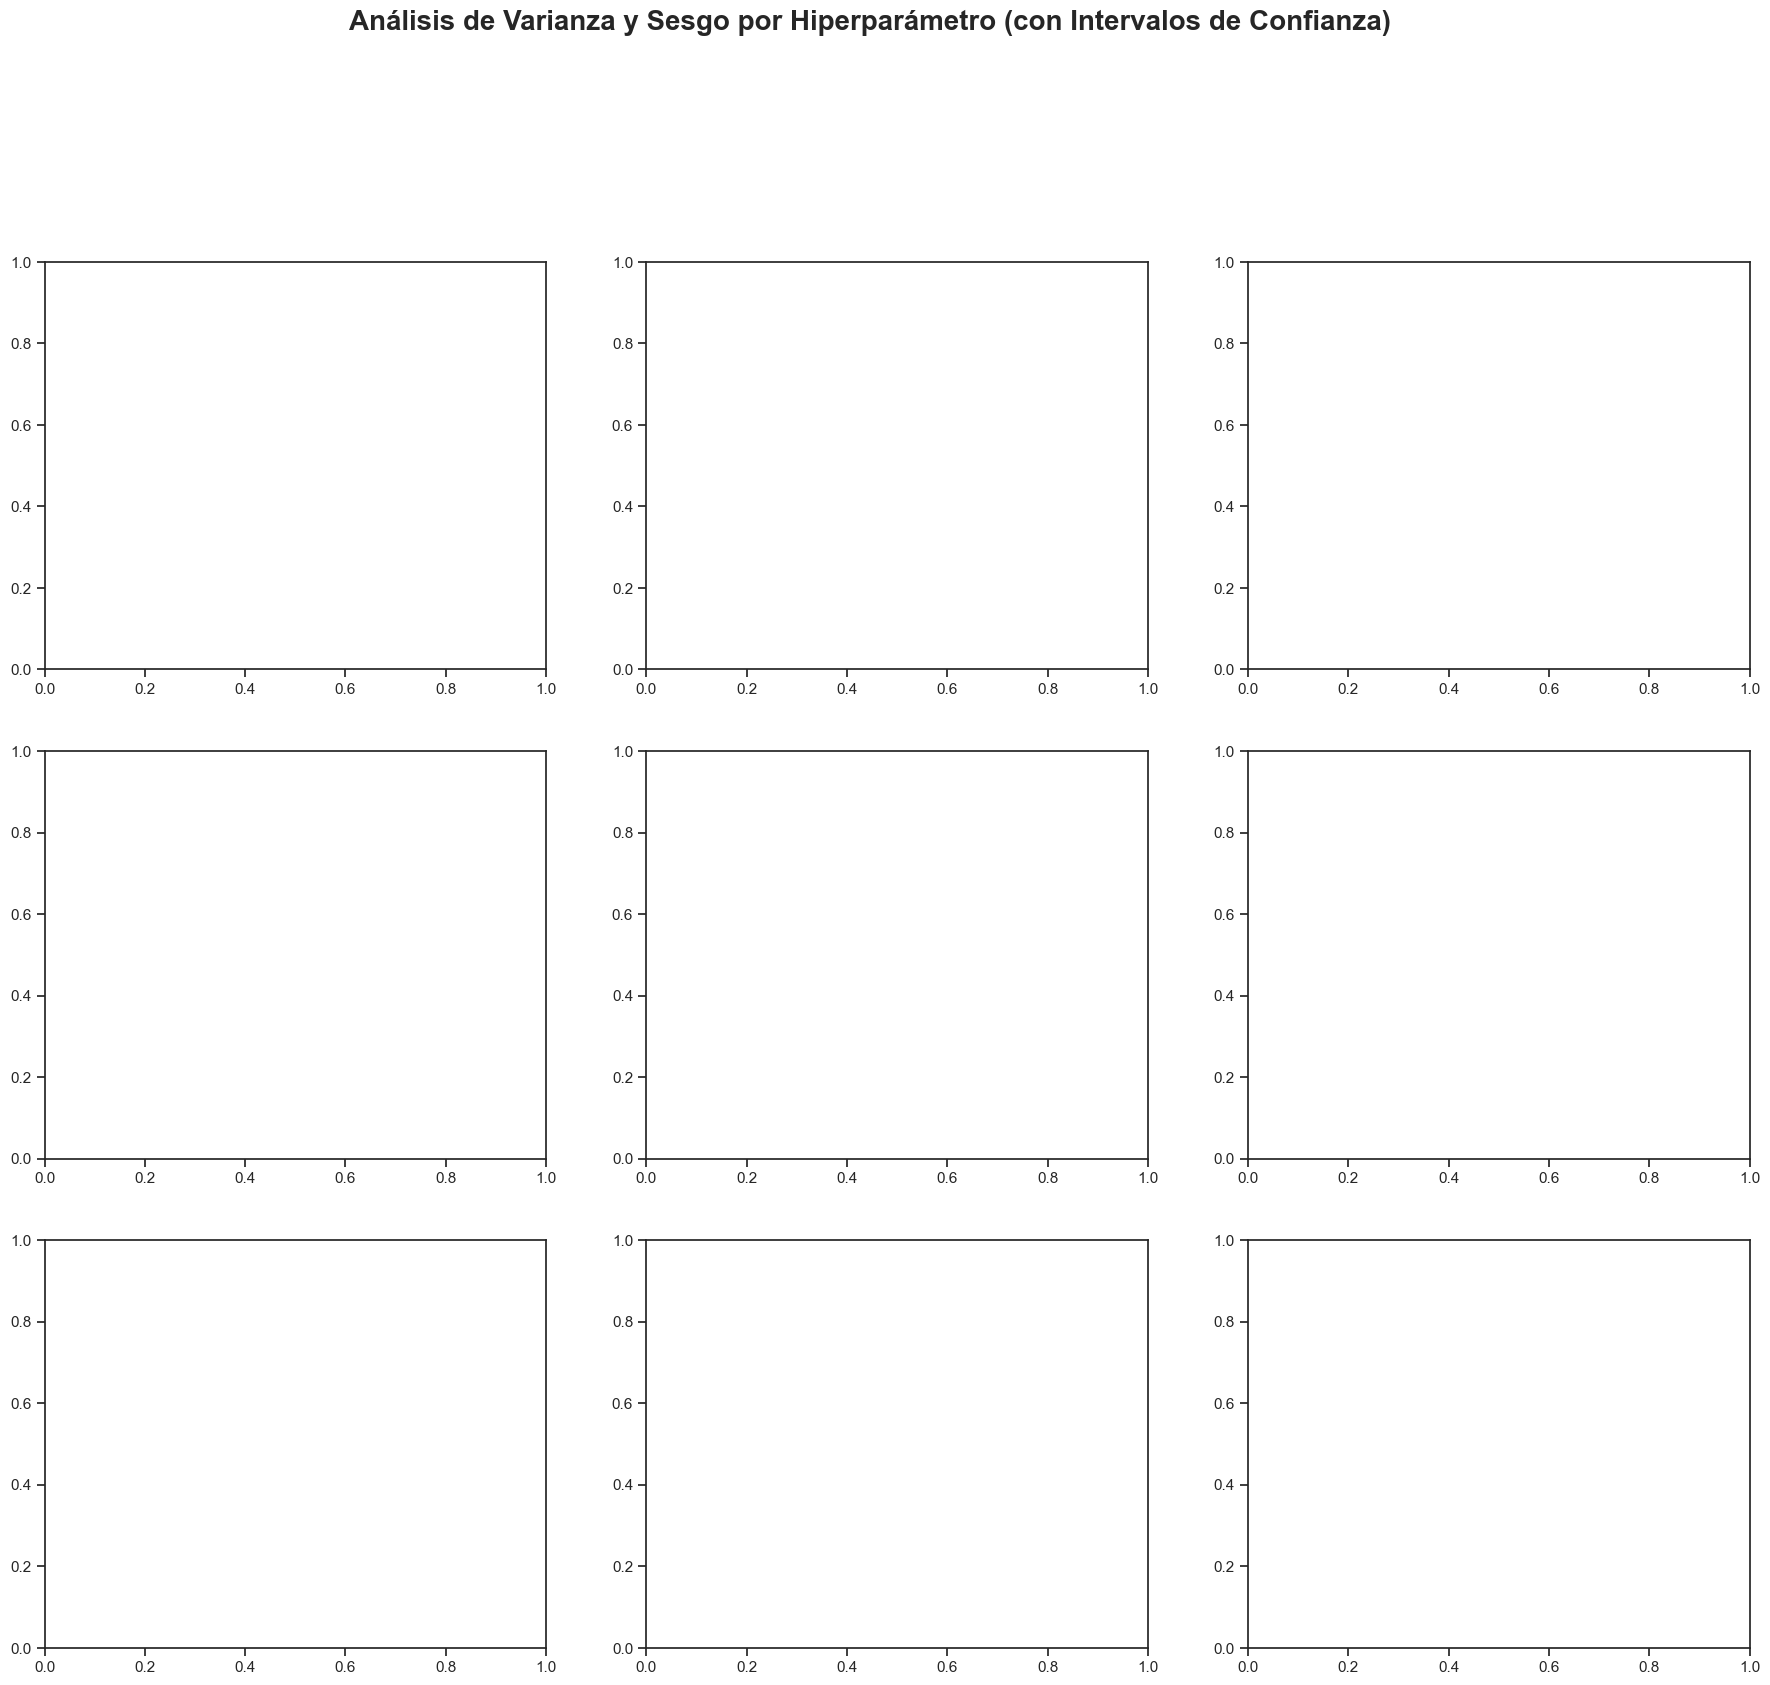

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, recall_score, f1_score
from sklearn.model_selection import StratifiedKFold

print("-> MATRIZ DE CURVAS DE VALIDACIÓN")
print("Evaluando max_depth, n_estimators y min_samples_split con CV de 5 pliegues\n")

# 1. Parámetros base (Tu configuración ganadora inamovible)
base_params = {
    'criterion': 'entropy',
    'max_features': None,
    'max_depth': 4,
    'min_samples_split': 7,
    'n_estimators': 75,
    'random_state': 42
}

# 2. Diccionario de hiperparámetros a explorar y sus rangos
param_grid_eval = {
    'max_depth': [2, 4, 6, 8, 12, 20, 30],
    'n_estimators': [10, 50, 75, 100, 200, 300, 500],
    'min_samples_split': [2, 5, 8, 15, 30, 50]
}

# Configuración de Cross Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Configuración del lienzo de gráficas (Matriz 3x3)
sns.set_theme(style="ticks")
fig, axes = plt.subplots(3, 3, figsize=(22, 18))
fig.suptitle('Análisis de Varianza y Sesgo por Hiperparámetro (con Intervalos de Confianza)', 
             fontsize=20, fontweight='bold', y=1.02)

# Función auxiliar para pintar cada subgráfica con las sombras
def plot_learning_curve(ax, x_vals, mean_t, std_t, mean_v, std_v, title, xlabel, ylabel):
    ax.plot(x_vals, mean_t, label='Train', marker='o', color='tab:blue', linewidth=2)
    ax.fill_between(x_vals, np.array(mean_t) - np.array(std_t), np.array(mean_t) + np.array(std_t), alpha=0.3, color='tab:blue')
    
    ax.plot(x_vals, mean_v, label='Validation', marker='o', color='tab:orange', linewidth=2)
    ax.fill_between(x_vals, np.array(mean_v) - np.array(std_v), np.array(mean_v) + np.array(std_v), alpha=0.3, color='tab:orange')
    
    ax.set_title(title, fontsize=14)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend(loc='best')
    ax.grid(True, linestyle='--', alpha=0.6)

# 3. Iteramos sobre cada parámetro y sus valores
print('Curvas de validación para valores númericos')
for row_idx, (param_name, param_values) in enumerate(param_grid_eval.items()):  
    metrics = {k: [] for k in ['t_acc_m', 't_acc_s', 'v_acc_m', 'v_acc_s', 
                               't_rec_m', 't_rec_s', 'v_rec_m', 'v_rec_s', 
                               't_f1_m',  't_f1_s',  'v_f1_m',  'v_f1_s']}
    
    for val in param_values:
        # Clonamos los parámetros base y actualizamos el que estamos evaluando
        current_params = base_params.copy()
        current_params[param_name] = val
        
        t_acc, v_acc, t_rec, v_rec, t_f1, v_f1 = [], [], [], [], [], []
        
        for train_idx, val_idx in cv.split(X_temp, y_temp):
            # Manejo seguro de índices para Pandas o Numpy
            if isinstance(X_temp, pd.DataFrame) or isinstance(X_temp, pd.Series):
                X_fold_train, X_fold_val = X_temp.iloc[train_idx], X_temp.iloc[val_idx]
                y_fold_train, y_fold_val = y_temp.iloc[train_idx], y_temp.iloc[val_idx]
            else:
                X_fold_train, X_fold_val = X_temp[train_idx], X_temp[val_idx]
                y_fold_train, y_fold_val = y_temp[train_idx], y_temp[val_idx]
            
            # Instanciamos el modelo inyectando los parámetros en tu clase
            modelo = SpotifyRandomForest(**current_params)
            modelo.fit(X_fold_train, y_fold_train)
            
            y_pred_train = modelo.predict(X_fold_train)
            y_pred_val = modelo.predict(X_fold_val)
            
            t_acc.append(accuracy_score(y_fold_train, y_pred_train))
            v_acc.append(accuracy_score(y_fold_val, y_pred_val))
            t_rec.append(recall_score(y_fold_train, y_pred_train))
            v_rec.append(recall_score(y_fold_val, y_pred_val))
            t_f1.append(f1_score(y_fold_train, y_pred_train))
            v_f1.append(f1_score(y_fold_val, y_pred_val))
            
        # Agregamos medias y desviaciones estándar
        metrics['t_acc_m'].append(np.mean(t_acc)); metrics['t_acc_s'].append(np.std(t_acc))
        metrics['v_acc_m'].append(np.mean(v_acc)); metrics['v_acc_s'].append(np.std(v_acc))
        metrics['t_rec_m'].append(np.mean(t_rec)); metrics['t_rec_s'].append(np.std(t_rec))
        metrics['v_rec_m'].append(np.mean(v_rec)); metrics['v_rec_s'].append(np.std(v_rec))
        metrics['t_f1_m'].append(np.mean(t_f1));   metrics['t_f1_s'].append(np.std(t_f1))
        metrics['v_f1_m'].append(np.mean(v_f1));   metrics['v_f1_s'].append(np.std(v_f1))

    # Graficamos la fila correspondiente a este parámetro
    plot_learning_curve(axes[row_idx, 0], param_values, metrics['t_acc_m'], metrics['t_acc_s'], metrics['v_acc_m'], metrics['v_acc_s'], f'Exactitud vs {param_name}', param_name, 'Accuracy')
    plot_learning_curve(axes[row_idx, 1], param_values, metrics['t_rec_m'], metrics['t_rec_s'], metrics['v_rec_m'], metrics['v_rec_s'], f'Sensibilidad vs {param_name}', param_name, 'Recall')
    plot_learning_curve(axes[row_idx, 2], param_values, metrics['t_f1_m'], metrics['t_f1_s'], metrics['v_f1_m'], metrics['v_f1_s'], f'F1-Score vs {param_name}', param_name, 'F1-Score')

plt.tight_layout()
plt.savefig("../docs/matriz_curvas_validacion.png", dpi=300, bbox_inches='tight')
plt.show()

print("\n Matriz gráfica exportada a 'docs/matriz_curvas_validacion.png'")

## Exploración de hiperparametros de regularización

### RandomizedSearchCV

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

print("-> FASE 1: EXPLORACIÓN AMPLIA (RandomizedSearchCV)")

rf_search = RandomForestClassifier(class_weight='balanced', random_state=42)

param_dist = {
    'n_estimators': [50, 100, 200, 300, 500],
    'max_depth': [5, 8, 12, 15, 20, 30, None],
    'min_samples_split': [2, 5, 8, 15, 30, 50],
    'max_features': ['sqrt', 'log2', None],
    'criterion': ['gini', 'entropy']
}

# 3. Configuramos la búsqueda para optimizar Recall e imprimir Top 5
random_search = RandomizedSearchCV(
    estimator=rf_search,
    param_distributions=param_dist,
    n_iter=20,                                            # Prueba 20 escenarios distintos
    scoring={'accuracy': 'accuracy', 'recall': 'recall'}, # Guardamos ambas métricas
    refit='recall',                                       # El ganador se decide por el mejor Recall
    cv=5,                                                 # Validación cruzada (Cross-Validation) de 5 pliegues
    random_state=42,
    n_jobs=-1,                                            # Usa todos los núcleos
    verbose=1
)

random_search.fit(X_train, y_train)

# 5. Extraemos resultados y filtramos el Top 5
results_rs = pd.DataFrame(random_search.cv_results_)
top_10_rs = results_rs.sort_values(by='rank_test_recall').head(10)

print("\nTOP 10 MODELOS (RandomizedSearchCV) ORDENADOS POR RECALL:")
print("-" * 65)
for i, row in top_10_rs.iterrows():
    puesto = int(row['rank_test_recall'])
    params = row['params']
    recall = row['mean_test_recall']
    accuracy = row['mean_test_accuracy']
    
    print(f"Puesto #{puesto}:")
    print(f"  Parámetros : {params}")
    print(f"  Recall     : {recall:.2%} (Métrica objetivo)")
    print(f"  Accuracy   : {accuracy:.2%}\n")

-> FASE 1: EXPLORACIÓN AMPLIA (RandomizedSearchCV)
Fitting 5 folds for each of 20 candidates, totalling 100 fits


KeyboardInterrupt: 

### GridSearchCV

In [ ]:
from sklearn.model_selection import GridSearchCV

print("--- FASE 2: BÚSQUEDA EXHAUSTIVA (GridSearchCV) ---")
# Alrededor de los parametros ganadores
param_grid = {
    'n_estimators': [75,100,125,275,300,325],      
    'max_depth': [4,5,6,7,8,9],            
    'min_samples_split': [7,8,9],    
    'max_features': ['log2',None],              
    'criterion': ['entropy']
}

grid_search = GridSearchCV(
    estimator=rf_search,
    param_grid=param_grid,
    scoring={'accuracy': 'accuracy', 'recall': 'recall'},
    refit='recall',
    cv=5,
    n_jobs=-1,
    verbose=1
)

# 3. Entrenamos todas las combinaciones posibles
grid_search.fit(X_train, y_train)

# 4. Extraemos el Top 5 final
results_gs = pd.DataFrame(grid_search.cv_results_)
top_5_gs = results_gs.sort_values(by='rank_test_recall').head(5)

print("\nTOP 5 MODELOS DEFINITIVOS (GridSearchCV) ORDENADOS POR RECALL:")
print("-" * 65)
for i, row in top_5_gs.iterrows():
    puesto = int(row['rank_test_recall'])
    params = row['params']
    recall = row['mean_test_recall']
    accuracy = row['mean_test_accuracy']
    
    print(f"Puesto #{puesto}:")
    print(f"  Parámetros : {params}")
    print(f"  Recall     : {recall:.2%}")
    print(f"  Accuracy   : {accuracy:.2%}\n")

# 5. La configuración ganadora lista para tu clase nativa
best_params = grid_search.best_params_
print("-" * 65)
print("INSTANCIACIÓN FINAL PARA main3.py:")
print(f"rf_reg = SpotifyRandomForest(")
for key, value in best_params.items():
    # Formateo condicional para strings vs números
    val_str = f"'{value}'" if isinstance(value, str) else value
    print(f"    {key}={val_str},")
print(f"    random_state=42\n)")

--- FASE 2: BÚSQUEDA EXHAUSTIVA (GridSearchCV) ---
Fitting 5 folds for each of 216 candidates, totalling 1080 fits

TOP 5 MODELOS DEFINITIVOS (GridSearchCV) ORDENADOS POR RECALL:
-----------------------------------------------------------------
Puesto #1:
  Parámetros : {'criterion': 'entropy', 'max_depth': 4, 'max_features': None, 'min_samples_split': 8, 'n_estimators': 75}
  Recall     : 61.13%
  Accuracy   : 79.03%

Puesto #1:
  Parámetros : {'criterion': 'entropy', 'max_depth': 4, 'max_features': None, 'min_samples_split': 8, 'n_estimators': 125}
  Recall     : 61.13%
  Accuracy   : 79.10%

Puesto #1:
  Parámetros : {'criterion': 'entropy', 'max_depth': 4, 'max_features': None, 'min_samples_split': 7, 'n_estimators': 125}
  Recall     : 61.13%
  Accuracy   : 79.10%

Puesto #1:
  Parámetros : {'criterion': 'entropy', 'max_depth': 4, 'max_features': None, 'min_samples_split': 9, 'n_estimators': 75}
  Recall     : 61.13%
  Accuracy   : 79.03%

Puesto #1:
  Parámetros : {'criterion': '